# Follow the Money - How EU Research Agenda Influences the Future of Society

### INSTRUCTIONS
Complete instructions on this [doc](https://pad.liiib.re/rXXeznogTyuTG2tfKYqfSA?view)
#### STEP 1) Choose a company from the [Super list](https://github.com/sciences-citoyennes/Future-Earth-Workshop/blob/main/Super%20List%20pdf.pdf)
   - The rest of the code will anaylse the top French projects that this company particpated in
   - You can pick multiple companies at once but the code will combine the results and not all steps distinguish between each company in the totals

#### STEP 2) Choose the Framework Programs to analyze:
   - 1 = Horizon Europe (2021 - 2027)
   - 2 = Horizon 2020 (2014 - 2020)
   - 3 = FP7 (2007 - 2013)
   - 4 = FP6 (2002 - 2006), note: this dataset is messy and has missing information so it may skew the results

#### OPTIONAL STEP) Choose Keywords from the European Science Vocabulary [(EuroSciVoc) List](https://op.europa.eu/en/web/eu-vocabularies/concept-scheme/-/resource?uri=http://data.europa.eu/8mn/euroscivoc/40c0f173-baa3-48a3-9fe6-d6e8fb366a00).
- *Note: go to table or list view to browse through them.*
- This will count how many times those keywords are used to describe the projects that the chosen company is a part of
- You can leave this list empty and it will plot all of the keywords in all of the projects
  
### STEP 5) Fill Out Choices In Cell Below


In [26]:
###### do not edit the imports ######
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 80)
#####################################

# STEP 1) Replace AIRBUS with chosen company name in CAPITAL LETTERS (can pick multiple companies but picking a single one first is suggested)
Entreprises = ['THALES']

Prog = {1: 'HORIZON', 2: 'H2020', 3: 'FP7'} #(4: 'FP6') excluding FP6 from the workshop because it is messy and has missing information

# STEP 2) Type the number followed by a comma for each of the Framework Programs you chose, for example: IncludeProgrammes = [1,2,3]
IncludeProgrammes = [1,2,3]

#OPTIONAL) type a few keywords from the official EuroSciVoc list, for example KeyWords = ['artificial intelligence','energy and fuels']
#   Leaving this blank will plot all of the keywords used to describe the project
KeyWords = []



### (Hidden) Filter data to find the total funding and the top funded projects

In [27]:
'''
## use this one when accessing data file from GitHub -- ie when using BINDER link
Clean_file = 'EU-fundings-TopFRcomp.csv'

TypeSpec = {'ecContribution': float,'Source': int,'Start Date': str,'netEcContribution': str} 
EUfullTable = pd.read_csv(Clean_file,dtype = TypeSpec) 
EUfullTable['EuroSciVoc'] = EUfullTable['EuroSciVoc'].fillna('[]').apply(lambda x: eval(x))

SourceSelect = EUfullTable['source'].apply(lambda x: x in IncludeProgrammes)
EUfullTable = EUfullTable.loc[SourceSelect]

SDateSeries = EUfullTable['Start Date'].str[0:4].fillna('9999').apply(lambda x: int(x))

'''
## use this one when accessing data file from laptop

CleanFolderName = '/Users/annalewicki/Downloads/Horizon Terre/Future Earth Atelier/code/' #replace with file location on your PC
Clean_file = 'EU-fundings-TopFRcomp.csv'

TypeSpec = {'ecContribution': float,'Source': int,'Start Date': str,'netEcContribution': str} 
EUfullTable = pd.read_csv(CleanFolderName + Clean_file,dtype = TypeSpec) 
EUfullTable['EuroSciVoc'] = EUfullTable['EuroSciVoc'].fillna('[]').apply(lambda x: eval(x))

SourceSelect = EUfullTable['source'].apply(lambda x: x in IncludeProgrammes)
EUfullTable = EUfullTable.loc[SourceSelect]

SDateSeries = EUfullTable['Start Date'].str[0:4].fillna('9999').apply(lambda x: int(x))

In [28]:
############# DO NOT EDIT ##############

### Find projects that chosen company is a part of from Clean Data (EU Fundings-TopFRcomp)

Entreprises = [x.upper() for x in Entreprises] # Put names all in capital letters 

if Entreprises != []: 
    IncludeTable = EUfullTable[['projectAcronym','Company']].groupby('projectAcronym').max()
    IncludeGroupIndex = IncludeTable['Company'].apply(lambda x: x in Entreprises)
    IncludeAc = set(IncludeTable['Company'].loc[IncludeGroupIndex].keys())
    IncludeIndex = EUfullTable['projectAcronym'].apply(lambda x: x in IncludeAc)
    EUfullTable = EUfullTable.loc[IncludeIndex]
else: 
    print(' ')
    print('COMPANY LIST EMPTY ! STATS ARE SHOWN FOR FULL LIST !')


##################### EXTRACT SERIES #####################

AcSeries = EUfullTable['projectAcronym']
SDateSeries = EUfullTable['Start Date']
LabsAndTOPSeries = EUfullTable['name']
TOPmainSeries = EUfullTable['Company']
FundSeries = EUfullTable['ecContribution']
CountrySeries = EUfullTable['country']

Nt = AcSeries.size # Total line number 


In [29]:
############# DO NOT EDIT ##############

### Calculate the Total Funding Company Recieves and Top 3 Funded Projects


# Top 3 Projects Recieving the most EU funding
TotalNum_Prog = EUfullTable[['projectAcronym','source']].groupby('projectAcronym').max().reset_index()
TotalNum_Prog = TotalNum_Prog['source'].value_counts()
TotalNum_Prog = TotalNum_Prog.rename(index = Prog) 
TotalNum_Prog['Somme total'] = np.sum(TotalNum_Prog)
TotalNum_ProgR = TotalNum_Prog[::-1] # Reverse order

# Total Funds per program
TotalFunds_Prog = EUfullTable[['ecContribution','source']].groupby('source',group_keys=False).sum()
TotalFunds_Prog = TotalFunds_Prog['ecContribution'].rename_axis(None, axis=0) 
TotalFunds_Prog = TotalFunds_Prog.rename(index = Prog).apply(lambda x: np.round(x/1e6)) # In Millions euros
TotalFunds_Prog['Somme total'] = np.sum(TotalFunds_Prog)
TotalFunds_ProgR = TotalFunds_Prog[::-1] # Reverse order


# Total funding per project
Project_TotFunds = EUfullTable[['projectAcronym','Title','ecContribution','EuroSciVoc']].groupby('projectAcronym').sum().reset_index()
Project_TotFunds['EuroSciVoc'] = Project_TotFunds['EuroSciVoc'].apply(lambda x: list(set(x)))
Project_TotFunds = Project_TotFunds.sort_values('ecContribution',ascending=False) 
Project_TotFunds['ecContribution'] = Project_TotFunds['ecContribution'].apply(lambda x: x/1e6)

Ntop_TotFunds = 3 # Number of highest projects to select  
Top3Project_TotFunds = Project_TotFunds.iloc[0:Ntop_TotFunds]

# Funding given to companies per project
def RepairNetC(x): 
    if x == 'false': 
        xr = 0 
    else: 
        xr = float(x)
    return xr 

EUcompTable = EUfullTable.loc[EUfullTable['Company'] != '-']
EUcompTable['netEcContribution'] = EUcompTable['netEcContribution'].apply(RepairNetC)

Project_GivenFunds = EUcompTable[['projectAcronym','Title','netEcContribution','EuroSciVoc']].groupby('projectAcronym').sum().reset_index()
Project_GivenFunds['EuroSciVoc'] = Project_GivenFunds['EuroSciVoc'].apply(lambda x: list(set(x)))
Project_GivenFunds = Project_GivenFunds.sort_values('netEcContribution',ascending=False) 
Project_GivenFunds['netEcContribution'] = Project_GivenFunds['netEcContribution'].apply(lambda x: x/1e6)

Top3Project_GivenFunds = Project_GivenFunds.iloc[0:Ntop_TotFunds]


/var/folders/vt/8n4nm62j3xv9bdx7fnpsmt_00000gn/T/ipykernel_5320/488782795.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EUcompTable['netEcContribution'] = EUcompTable['netEcContribution'].apply(RepairNetC)


# Main Info
#### STEP 6) Run the code by clicking on 'Run' in the menu bar and selecting 'Run All Cells'.
This will run the entire code all at once and all you have to do is scroll through to find the information you need. **Remember to Run All Cells every time you change your selections in step 5**


#### STEP 7) Fill out Worksheet Using Outputed Info Below
From the printed results of Main Info start filling in the Worksheet below (Company name, the total sum of money recieved over selected programs, and the top project acronym and title)

**Note: For 'Top projects' the first column is just the number of the row in the data sheet, ignore it!**

In [31]:
############# DO NOT EDIT ##############
print(' ')
print('Top 3 projects the company receives the most public money from:')
print(Top3Project_GivenFunds)

## work in progress, right now it sums to ecContrinution but that leads to the total amount of euros allocated to the project
## we need to edit it so that it sums netEcContribution to get the amount of euros the company receives directly
'''
print(' ')
print('Total Sum (in M €):')
print(TotalFunds_Prog)

print(' ')
print('Most expensive projets company is a part of:')
print(Top3Project_TotFunds)

print(' ')
print('Number of projets:')
print(TotalNum_Prog)
'''

 
Top 3 projects the company receives the most public money from:
    projectAcronym  \
351   LPA GAM 2018   
251   GAM-2020-LPA   
249   GAM AIR 2018   

                                                                               Title  \
351  Large Passenger AircraftLarge Passenger AircraftLarge Passenger AircraftLarg...   
251  Large Passenger Aircraft Innovative Aircraft Demonstrator PlatformLarge Pass...   
249  AIRFRAME ITDAIRFRAME ITDAIRFRAME ITDAIRFRAME ITDAIRFRAME ITDAIRFRAME ITDAIRF...   

     netEcContribution  \
351          90.075862   
251          76.919175   
249          60.856847   

                                                                          EuroSciVoc  
351                                   [aircraft, additive manufacturing, fuel cells]  
251                                                                       [aircraft]  
249  [composites, rotorcraft, aeronautical engineering, climatic change mitigatio...  


"\nprint(' ')\nprint('Total Sum (in M €):')\nprint(TotalFunds_Prog)\n\nprint(' ')\nprint('Most expensive projets company is a part of:')\nprint(Top3Project_TotFunds)\n\nprint(' ')\nprint('Number of projets:')\nprint(TotalNum_Prog)\n"

### Step 8) Explore the graphs outputted in the next sections

### Plot Set up

In [32]:
Font=14
plt.rc('text', usetex=False) # FORCE NO LATEX
plt.rc('font',size=Font)
plt.rc('font',family='serif')

## Plot : AMOUNT OF MONEY COMPANY REVIECED AS PART OF TOP PROJECTS

Text(0.5, 0, 'M €')

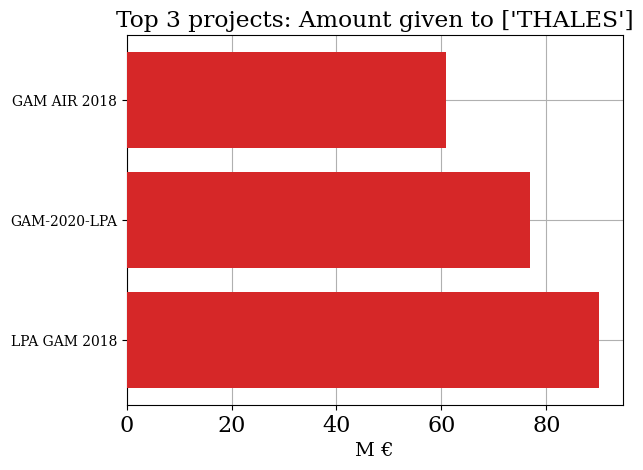

In [33]:
#####################
# Top 3 projects: given funds 
##################### 

plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(Top3Project_GivenFunds['projectAcronym'],Top3Project_GivenFunds['netEcContribution'],color = 'tab:red',zorder=3) 
plt.grid()
plt.title('Top '+str(Ntop_TotFunds)+' projects: Amount given to '+str(Entreprises)+'')
plt.xlabel('M €')

## Plot: TOP PROJECTS GIVEN THE MOST FUNDING

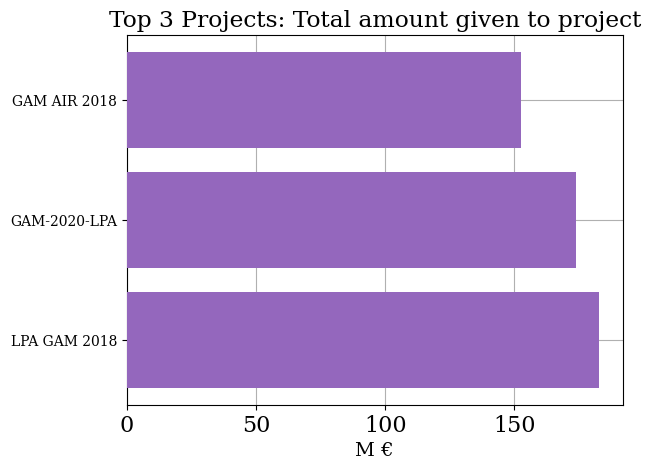

In [44]:
"""
#####################
# Top 3 projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(Top3Project_TotFunds['projectAcronym'],Top3Project_TotFunds['ecContribution'],color = 'tab:purple',zorder=3) 
plt.grid()
plt.title('Top '+str(Ntop_TotFunds)+' Projects: Total amount given to project')
plt.xlabel('M €')
plt.show()


## Plot: NUMBER OF PROJECTS PER PROGRAMME

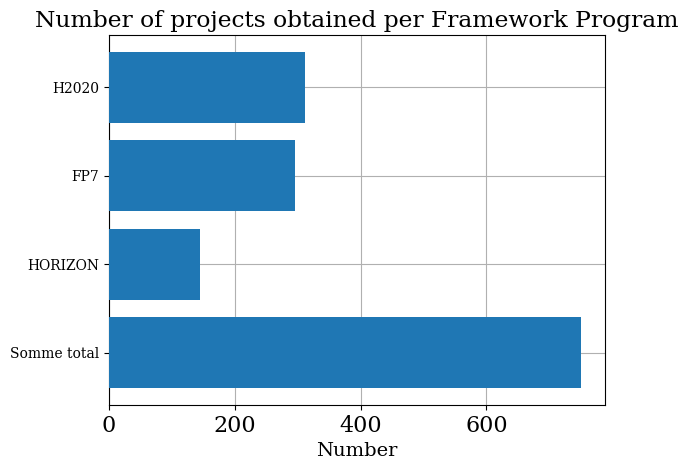

In [35]:
"""
#####################
# Comp. number of projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(TotalNum_ProgR.index,TotalNum_ProgR,color = 'tab:blue',zorder=3) 
plt.grid()
plt.title('Number of projects obtained per Framework Program')
plt.xlabel('Number')
plt.show()

## [under construction] Plot: soon it will show sum total obtained per Framework Program'

In [43]:
###need to change it from summing ecContribution (that sums the total amount for prjects)
### to netEcContribution that should sum total amount obtained by company
'''
"""
#####################
# Comp. fundings of projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(TotalFunds_ProgR.index,TotalFunds_ProgR,color = 'tab:orange',zorder=3) 
plt.grid()
plt.title('Sum total obtained per Framework Program')
plt.xlabel('M €')
plt.show()
'''

'\n"""\n#####################\n# Comp. fundings of projects \n##################### \n"""\nplt.rc(\'ytick\', labelsize=10) \nplt.rc(\'xtick\', labelsize=16) \nplt.figure() \nplt.barh(TotalFunds_ProgR.index,TotalFunds_ProgR,color = \'tab:orange\',zorder=3) \nplt.grid()\nplt.title(\'Sum total obtained per Framework Program\')\nplt.xlabel(\'M €\')\nplt.show()\n'

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## KEYWORDS STATS 

This plot collects the keywords over all of the projects of the chosen company and counts how many times they were used. It will either plot all of the keywords or only the chosen ones you typed in the first step.

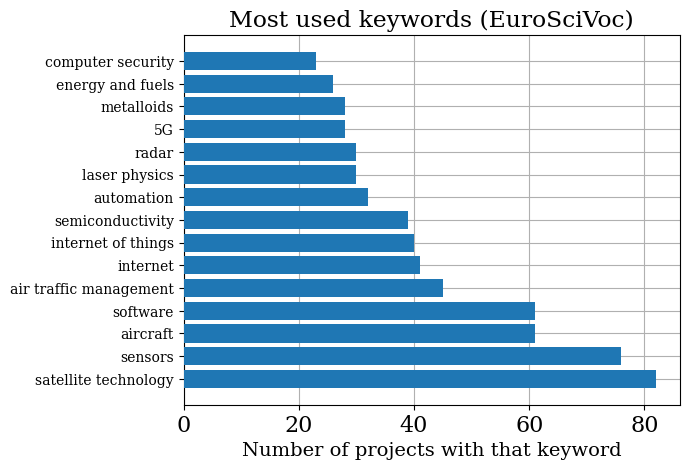

In [38]:
KeyWords_Nlist = list(EUfullTable.drop_duplicates(subset=['projectAcronym'])['EuroSciVoc']) # gives a nested list 
KeyWords_list = [item for sublist in KeyWords_Nlist for item in sublist] # Flatten the nested list 
KeyWords_set = set(KeyWords_list)

KeyWords_Count = pd.Series(KeyWords_list).value_counts() 
Nkw = 15 # Number of keywords to show 

KeyWords_RCount = KeyWords_Count.iloc[0:Nkw] 

if len(KeyWords) > 0: 
    for jk in KeyWords: 
        if jk not in KeyWords_set: 
            print(' ')
            print('Keyword "'+jk+'" not in the standard EuroSciVoc list! Has been removed.')
            KeyWords.remove(jk) 
    KeyWords_selected_index = pd.Series(KeyWords_Count.index).apply(lambda x: x in KeyWords)
    KeyWords_selected_index.index = KeyWords_Count.index 
    KeyWords_selected = KeyWords_Count.loc[KeyWords_selected_index] 

"""
#####################
#   Keywords count 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
if len(KeyWords)>0: 
    plt.figure() 
    plt.barh(KeyWords_selected.index,KeyWords_selected,zorder=3) 
    plt.grid()
    plt.title('Occurences of chosen keywords (EuroSciVoc)')
    plt.xlabel('Number of projects with that keyword')
else: 
    plt.figure() 
    plt.barh(KeyWords_RCount.index,KeyWords_RCount,zorder=3) 
    plt.grid()
    plt.title('Most used keywords (EuroSciVoc)')
    plt.xlabel('Number of projects with that keyword')

plt.show()